<a href="https://colab.research.google.com/github/bonkacardonut/tts-pred/blob/main/XGBoostHPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import make_scorer, f1_score, confusion_matrix, recall_score, precision_score
from scipy.stats import randint, loguniform, uniform
import pandas as pd
import numpy as np

In [ ]:
# load data
df = pd.read_csv('/TTS_all4_data_v3.csv')

In [ ]:
# ITERATIVE RANDOM SEARCH
# ------------------

# Separate features from target and remove patient IDs
X = df.drop(columns=['all-cause death', 'new code'], axis=1)
y = df['all-cause death']

# Weighted F1 scorer
f1_scorer = make_scorer(f1_score, average='weighted')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Define base XGBoost classifier
num_classes = len(y.unique())
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='mlogloss',
    use_label_encoder=False,
    enable_categorical=True,
    random_state=42
)

# RANDOM SEARCH #1
# Random search to explore wide parameter ranges
random_param_dist = {
    'n_estimators': randint(50, 100),
    'max_depth': randint(2, 20),
    'learning_rate': loguniform(1e-6, 1e-0), # explore 10^-6 to 10^0
    'subsample': uniform(0.5,0.5),
    'colsample_bytree': uniform(0.5, 0.5)
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=random_param_dist,
    n_iter=80,                     # number of random combinations to try
    scoring=f1_scorer,
    cv=None, # none: 5-fold default
    n_jobs=-1, # uses all processors to run the method
    verbose=2, # print computation time, parameter candidate, and score
    random_state=42
)

# Run random search
random_search.fit(X_train, y_train)

print("Best parameters from Random Search:", random_search.best_params_)
print("Best weighted F1 from Random Search:", random_search.best_score_)

# Evaluate best model
best_model = random_search.best_estimator_ # best_estimator_ automatic after doing .fit()

y_pred = best_model.predict(X_test)

# Metrics
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')   # sensitivity (true positive rate)
precision = precision_score(y_test, y_pred, average='weighted')  # specificity (true negative rate)

print("\n Final Model Evaluation:")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"Specificity (Precision): {precision:.4f}")

# Plot Feature Importance
import matplotlib.pyplot as plt

feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.xticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx], rotation=90)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------------------------------------------------------------------

# ITERATION 2: ITERATIVE RANDOM SEARCH
# ------------------

# Separate features from target and remove patient IDs
X = df.drop(columns=['all-cause death', 'new code'], axis=1)
y = df['all-cause death']

# Weighted F1 scorer
f1_scorer = make_scorer(f1_score, average='weighted')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Define base XGBoost classifier
num_classes = len(y.unique())
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='mlogloss',
    use_label_encoder=False,
    enable_categorical=True,
    random_state=42
)

# RANDOM SEARCH #1
# Random search to explore wide parameter ranges
random_param_dist = {
    'n_estimators': randint(50, 70),
    'max_depth': randint(8, 15),
    'learning_rate': uniform(0.4, 0.6), # explore 10^-6 to 10^0
    'subsample': uniform(loc=0.6, scale=0.2),
    'colsample_bytree': uniform(loc=0.6, scale=0.2)
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=random_param_dist,
    n_iter=30,                     # number of random combinations to try
    scoring=f1_scorer,
    cv=None, # none: 5-fold default
    n_jobs=-1, # uses all processors to run the method
    verbose=2, # print computation time, parameter candidate, and score
    random_state=42
)

# Run random search
random_search.fit(X_train, y_train)

print("Best parameters from Random Search:", random_search.best_params_)
print("Best weighted F1 from Random Search:", random_search.best_score_)

# Evaluate best model
best_model = random_search.best_estimator_ # best_estimator_ automatic after doing .fit()

y_pred = best_model.predict(X_test)

# Metrics
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')   # sensitivity (true positive rate)
precision = precision_score(y_test, y_pred, average='weighted')  # specificity (true negative rate)

print("\n Final Model Evaluation:")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"Specificity (Precision): {precision:.4f}")

# Plot Feature Importance
import matplotlib.pyplot as plt

feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.xticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx], rotation=90)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [ ]:
class_counts = df['all-cause death'].value_counts()
class_counts
# very imbalanced

,count
all-cause death,
0,644
1,78


Fitting 5 folds for each of 60 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:04:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters from Random Search: {'colsample_bytree': np.float64(0.6219948216895418), 'learning_rate': np.float64(0.39731673315798577), 'max_depth': 14, 'n_estimators': 57, 'subsample': np.float64(0.8155693129986314)}
Best weighted F1 from Random Search: 0.8526090375064932
Training Metrics
Train Weighted F1: 1.0000
Train Sensitivity (Recall): 1.0000
Train Specificity (Precision): 1.0000

 Final Model Evaluation:
Weighted F1 Score: 0.8534
Sensitivity (Recall): 0.8848
Specificity (Precision): 0.8404


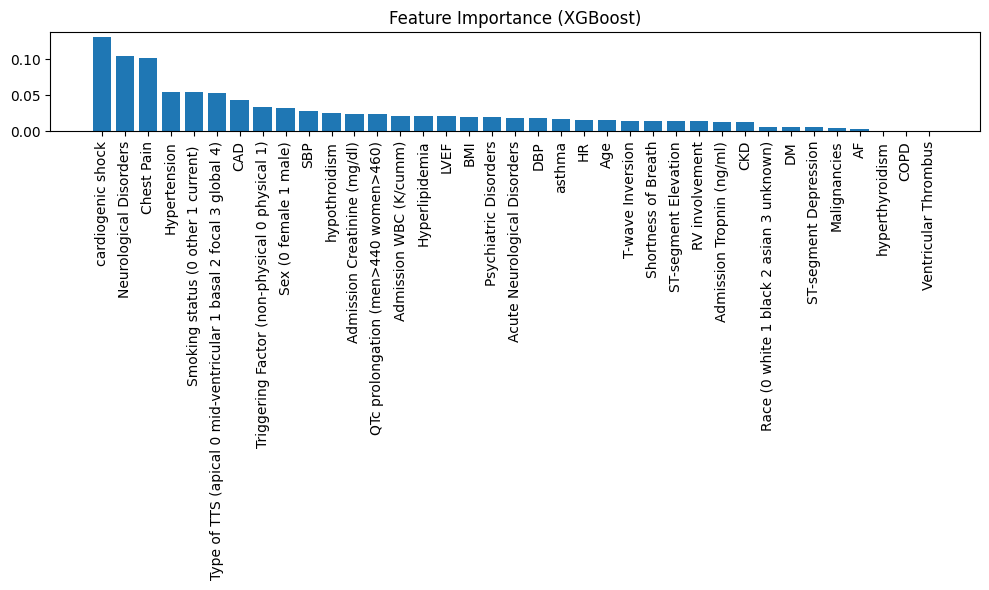

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:04:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters from Random Search: {'colsample_bytree': np.float64(0.5293016342019151), 'learning_rate': np.float64(0.5345900682272313), 'max_depth': 16, 'n_estimators': 47, 'subsample': np.float64(0.6485530730333811)}
Best weighted F1 from Random Search: 0.8699236083887664
Training Metrics
Train Weighted F1: 1.0000
Train Sensitivity (Recall): 1.0000
Train Specificity (Precision): 1.0000

 Final Model Evaluation:
Weighted F1 Score: 0.8531
Sensitivity (Recall): 0.8756
Specificity (Precision): 0.8394


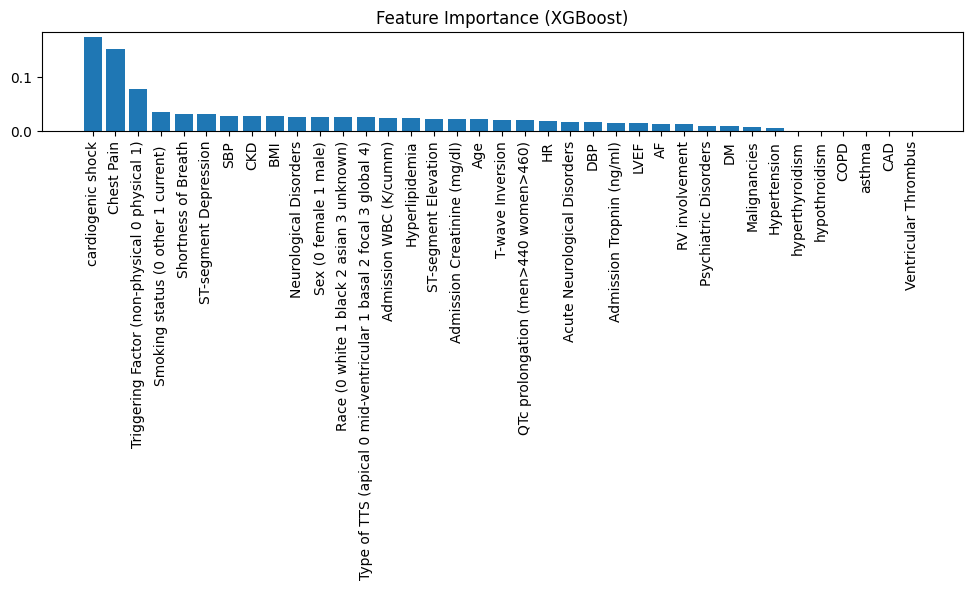

In [ ]:
# ITERATIVE RANDOM SEARCH
# ------------------

# Separate features from target and remove patient IDs
X = df.drop(columns=['all-cause death', 'new code'], axis=1)
y = df['all-cause death']

# Weighted F1 scorer
f1_scorer = make_scorer(f1_score, average='weighted')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Define base XGBoost classifier
num_classes = len(y.unique())
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='mlogloss',
    use_label_encoder=False,
    enable_categorical=True,
    random_state=42
)

#### RANDOM SEARCH #1 #####
# Random search to explore wide parameter ranges
random_param_dist = {
    'n_estimators': randint(50, 100),
    'max_depth': randint(2, 15),
    'learning_rate': loguniform(1e-4, 5e-1), # explore 10^-6 to 10^0
    'subsample': uniform(0.5,0.5), # ranges from 0.5 to 1.0 (lower bound: 0.5, scale: 0.5)
    'colsample_bytree': uniform(0.5, 0.5) # ranges 0.5 to 1.0
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=random_param_dist,
    n_iter=60,                     # number of random combinations to try
    scoring=f1_scorer,
    cv=None, # none: 5-fold default
    n_jobs=-1, # uses all processors to run the method
    verbose=2, # print computation time, parameter candidate, and score
    random_state=42
)

# Run random search
random_search.fit(X_train, y_train)

print("Best parameters from Random Search:", random_search.best_params_)
print("Best weighted F1 from Random Search:", random_search.best_score_)

# Evaluate best model
best_model = random_search.best_estimator_ # best_estimator_ automatic after doing .fit()

y_pred = best_model.predict(X_test)

# Train Metrics
y_train_pred = best_model.predict(X_train)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_precision = precision_score(y_train, y_train_pred, average='weighted')

print("Training Metrics")
print(f"Train Weighted F1: {train_f1:.4f}")
print(f"Train Sensitivity (Recall): {train_recall:.4f}")
print(f"Train Specificity (Precision): {train_precision:.4f}")

# Test Metrics
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')   # sensitivity (true positive rate)
precision = precision_score(y_test, y_pred, average='weighted')  # specificity (true negative rate)

print("\n Final Model Evaluation:")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"Specificity (Precision): {precision:.4f}")

# Plot Feature Importance
import matplotlib.pyplot as plt

feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.xticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx], rotation=90)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------------------------------------------------------------------

# ITERATION 2: ITERATIVE RANDOM SEARCH
# ------------------------------------

# Separate features from target and remove patient IDs
X = df.drop(columns=['all-cause death', 'new code'], axis=1)
y = df['all-cause death']

# Weighted F1 scorer
f1_scorer = make_scorer(f1_score, average='weighted')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=10
)

# Define base XGBoost classifier
num_classes = len(y.unique())
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='mlogloss',
    use_label_encoder=False,
    enable_categorical=True,
    random_state=42
)

# Random search to explore wide parameter ranges
random_param_dist = {
    # all parameters are approx. +-30% of the best parameter values from iteration 1
    'n_estimators': randint(36, 67),
    'max_depth': randint(10, 20),
    'learning_rate': loguniform(3.5e-1, 6.5e-1),
    'subsample': uniform(0.5, 0.3),
    'colsample_bytree': uniform(0.5, 0.3)
}

#### RANDOM SEARCH #2 #####
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=random_param_dist,
    n_iter=30,                     # number of random combinations to try
    scoring=f1_scorer,
    cv=None, # none: 5-fold default
    n_jobs=-1, # uses all processors to run the method
    verbose=2, # print computation time, parameter candidate, and score
    random_state=42
)

# Run random search
random_search.fit(X_train, y_train)

print("Best parameters from Random Search:", random_search.best_params_)
print("Best weighted F1 from Random Search:", random_search.best_score_)

# Evaluate best model
best_model = random_search.best_estimator_ # best_estimator_ automatic after doing .fit()

y_pred = best_model.predict(X_test)

# Train Metrics
y_train_pred = best_model.predict(X_train)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_precision = precision_score(y_train, y_train_pred, average='weighted')

print("Training Metrics")
print(f"Train Weighted F1: {train_f1:.4f}")
print(f"Train Sensitivity (Recall): {train_recall:.4f}")
print(f"Train Specificity (Precision): {train_precision:.4f}")

# Test Metrics
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')   # sensitivity (true positive rate)
precision = precision_score(y_test, y_pred, average='weighted')  # specificity (true negative rate)

print("\n Final Model Evaluation:")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"Specificity (Precision): {precision:.4f}")

# Plot Feature Importance
import matplotlib.pyplot as plt

feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.xticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx], rotation=90)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()